<a href="https://colab.research.google.com/github/deepanshurawat43-cpu/DL-Project/blob/main/Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 - Installs and Imports

!pip install torch numpy pandas gtts gradio tqdm matplotlib --quiet

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import gradio as gr
import random, re, os, math
from gtts import gTTS
from tqdm import tqdm
from IPython.display import Audio, display
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
print("✅ Ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0.24.0, but you have typer 0.23.1 which is incompatible.
PyTorch : 2.10.0+cu128
Device  : cuda
✅ Ready


In [2]:
# Cell 2 - Parallel Dataset (English/Hindi → Garhwali)

data = [
    # GREETINGS
    ("hello how are you",                        "नमस्कार तू कनै च"),
    ("good morning",                             "भ्यार कि नमस्कार"),
    ("good evening",                             "साँझ कि नमस्कार"),
    ("good night",                               "राति कि नमस्कार"),
    ("welcome to our village",                   "हमरि गौं मा स्वागत च"),
    ("how are you today",                        "तू आज कनै च"),
    ("i am fine thank you",                      "मि ठीक छौं धन्यवाद"),
    ("nice to meet you",                         "तिकें मिलिक खुशी भे"),
    ("see you tomorrow",                         "भोल मिलला"),
    ("take care of yourself",                    "अपण ख्याल रख"),
    ("how is everyone at home",                  "घर मा सब कनै छन"),
    ("i am doing well",                          "मि ठीक छौं"),
    ("hello friend",                             "नमस्कार दोस्त"),
    ("blessings to you",                         "तिकें आशीर्वाद च"),
    ("may god bless you",                        "भगवान तिकें खुश रखो"),

    # FAMILY
    ("my mother is very good",                   "मेरि ईजा बोत ठीक च"),
    ("my father works hard",                     "मेरु बाबू बोत काम करद"),
    ("she is my sister",                         "वा मेरि बैणि च"),
    ("he is my brother",                         "वो मेरु भुलु च"),
    ("my grandmother tells stories",             "मेरि आजी कहाणि बतौंदि"),
    ("my grandfather is very old",               "मेरु दादा बोत बुड्ड च"),
    ("my son goes to school",                    "मेरु छौं स्कूल जांद"),
    ("my daughter is very smart",                "मेरि छ्वरी बोत होशियार च"),
    ("our family lives in the village",          "हमरु परिवार गौं मा रौंद"),
    ("my uncle is a farmer",                     "मेरु काका किसान च"),
    ("my aunt cooks very well",                  "मेरि काकी बोत ठीक खाणु बणौंदि"),
    ("i love my family",                         "मि अपण परिवार बटी माया करदु"),
    ("my parents are very kind",                 "मेरि ईजा बाबू बोत दयालु छन"),
    ("we are four members in family",            "हम परिवार मा चार जणा छौं"),
    ("my brother studies in college",            "मेरु भुलु कॉलेज मा पढ़द"),
    ("my mother cooks food daily",               "मेरि ईजा रोज खाणु बणौंदि"),
    ("my father goes to field",                  "मेरु बाबू खेत जांद"),
    ("my sister is younger than me",             "मेरि बैणि मिबटी छोटि च"),
    ("grandmother loves me a lot",               "आजी मिबटी बोत माया करदि"),
    ("grandfather sits in the sun",              "दादा घाम मा बैठदन"),
    ("my family is very happy",                  "मेरु परिवार बोत रमाण च"),

    # DAILY LIFE
    ("i wake up early in the morning",           "मि भ्यार जल्दी उठदु"),
    ("i eat breakfast in the morning",           "मि भ्यार नाश्ता खांदु"),
    ("i go to school by walking",                "मि पैदल स्कूल जांदु"),
    ("i come back home in the evening",          "मि साँझ घर वापस ऐंदु"),
    ("i drink milk every day",                   "मि रोज दूद पींद छौं"),
    ("i sleep at night",                         "मि राति सोंद छौं"),
    ("i read books at night",                    "मि राति किताब पढ़दु"),
    ("i help my mother in kitchen",              "मि ईजा कि रसोई मा मदद करदु"),
    ("we eat food together",                     "हम सब मिलिक खाणु खांदा"),
    ("i wash my clothes",                        "मि अपण कपड़ धोंदु"),
    ("i play with my friends",                   "मि दोस्तों कसांत खेलदु"),
    ("i watch the stars at night",               "मि राति तारा देखदु"),
    ("we sit together in the evening",           "हम साँझ मिलिक बैठदा"),
    ("i take bath in the morning",               "मि भ्यार नाण करदु"),
    ("i clean the house today",                  "मि आज घर साफ करदु"),
    ("i fetch water from the river",             "मि गाड़ बटी पाणि लींदु"),
    ("i cook food in the evening",               "मि साँझ खाणु बणौंदु"),
    ("i go to the market on sunday",             "मि रविवार बाजार जांदु"),
    ("i milk the cow every morning",             "मि रोज भ्यार गौ कु दूद काढ़दु"),

    # NATURE & UTTARAKHAND
    ("the mountain is very big",                 "पहाड़ बोत ब्वड़ च"),
    ("the river is cold",                        "गाड़ बोत ठंडि च"),
    ("the village is beautiful",                 "गौं बोत सुन्दर च"),
    ("the forest is very dense",                 "जंगल बोत घना च"),
    ("the sun is hot today",                     "आज घाम बोत तातु च"),
    ("it is raining today",                      "आज बरखा ह्वे रईं च"),
    ("snow falls in winter",                     "जाड़ मा बरफ पड़दि"),
    ("the flowers bloom in spring",              "बसंत मा फूल खिलदन"),
    ("the air here is very fresh",               "यख कि हवा बोत ताजि च"),
    ("the water of this river is sweet",         "इ गाड़ कु पाणि मीठु च"),
    ("our mountains touch the sky",              "हमरा पहाड़ आकाश छूंदन"),
    ("the birds sing in the morning",            "भ्यार चिड़ि गौंदि"),
    ("the trees are very tall here",             "यख दरख्त बोत ऊँचा छन"),
    ("the valley looks very beautiful",          "घाटी बोत सुन्दर दिखदि"),
    ("uttarakhand is my homeland",               "उत्तराखंड मेरि जन्मभूमि च"),
    ("garhwal is land of gods",                  "गढ़वाल देवभूमि च"),
    ("the himalaya is our pride",                "हिमालय हमरु गर्व च"),
    ("the paths here are very steep",            "यखकि बाट बोत खड़ी छन"),
    ("clouds cover the mountains",               "बादल पहाड़ ढकि लींदन"),
    ("the moon looks beautiful tonight",         "आज राति चन्द्रमा बोत सुन्दर दिखद"),
    ("the waterfall is very high",               "झरणु बोत ऊँचु च"),
    ("the spring water is very cold",            "नौला कु पाणि बोत ठंडु च"),
    ("the fog covers the village",               "कुहरु गौं ढकि लींद"),
    ("wild animals live in forest",              "जंगली जनवर जंगल मा रौंदन"),
    ("the sunset looks beautiful here",          "यख अस्त होंदु घाम बोत सुन्दर दिखद"),

    # FOOD
    ("the food is very tasty",                   "खाणु बोत मीठु च"),
    ("i want to eat food",                       "मिकें खाणु खाणु च"),
    ("give me water please",                     "मिकें पाणि दे"),
    ("i am hungry",                              "मिकें भूख लगि च"),
    ("i am thirsty",                             "मिकें तिरास लगि च"),
    ("the rice is cooked well",                  "चौंळ बोत ठीक पकि च"),
    ("mother makes very tasty roti",             "ईजा बोत मीठि रोटि बणौंदि"),
    ("we eat dal rice every day",                "हम रोज दाळ चौंळ खांदा"),
    ("salt is less in the food",                 "खाणु मा नूण कम च"),
    ("i like to eat sweets",                     "मिकें मिठाई खाणु पसंद च"),
    ("the tea is very hot",                      "चाय बोत तातु च"),
    ("the fruit from this tree is sweet",        "इ रुखु कु फल मीठु च"),
    ("i drink two glasses of milk",              "मि दुइ गिलास दूद पींदु"),
    ("the curry is very spicy",                  "साग बोत तीखु च"),
    ("the ghee is very pure",                    "घ्यू बोत शुद्ध च"),
    ("i want hot tea",                           "मिकें तातु चाय चइं"),
    ("the pickle is very sour",                  "अचार बोत खट्टु च"),

    # SCHOOL & EDUCATION
    ("i am going to school",                     "मि स्कूल जांद छौं"),
    ("i study every day",                        "मि रोज पढ़दु"),
    ("our teacher is very good",                 "हमरु मास्टर बोत ठीक च"),
    ("i like mathematics",                       "मिकें गणित पसंद च"),
    ("i write in my notebook",                   "मि अपणि कॉपी मा लिखदु"),
    ("the school is far from home",              "स्कूल घर बटी दूर च"),
    ("i got first rank in class",                "मि क्लास मा पैलु आयु"),
    ("we have holiday tomorrow",                 "भोल छुट्टी च"),
    ("my bag is very heavy",                     "मेरु बस्ता बोत भारी च"),
    ("our school has a big playground",          "हमरा स्कूल मा ब्वड़ मैदान च"),
    ("the exam is next week",                    "अगलि हफ्त परीक्षा च"),
    ("we learn new things every day",            "हम रोज नयि चीज सीखदा"),
    ("education is very important",              "पढ़ाई बोत जरूरी च"),
    ("i want to become a doctor",                "मि डॉक्टर बणणु चांदु"),
    ("science is my favourite subject",          "विज्ञान मेरु मनपसंद विषय च"),
    ("i passed my exam",                         "मि परीक्षा पास करु"),
    ("our teacher teaches very well",            "हमरु मास्टर बोत ठीक पढ़ौंद"),

    # EMOTIONS
    ("i am very happy today",                    "मि आज बोत रमाण छौं"),
    ("i am feeling sad",                         "मि दुखि महसूस करदु"),
    ("i am very angry",                          "मि बोत गुस्सा मा छौं"),
    ("i miss my village",                        "मिकें अपणि गौं याद ऐंदि"),
    ("i feel proud of my culture",               "मिकें अपणि संस्कृति पर गर्व च"),
    ("i am tired today",                         "मि आज थकि गयु"),
    ("i am excited about the festival",          "मिकें त्यौहार कि खुशी च"),
    ("i love the smell of rain",                 "मिकें बरखा कि खुशबू पसंद च"),
    ("i feel peaceful in the mountains",         "पहाड़ मा मिकें शांति मिलदि"),
    ("i am nervous before the exam",             "परीक्षा बटी पैलि मि घबरौंदु"),

    # QUESTIONS
    ("where are you going",                      "तू कख जांद"),
    ("what is your name",                        "तेरु नाम क्या च"),
    ("how old are you",                          "तू कति उमर कु च"),
    ("where do you live",                        "तू कख रौंद"),
    ("what do you want to eat",                  "तू क्या खाणु चांद"),
    ("when will you come",                       "तू कब ऐलु"),
    ("who is that person",                       "वो को च"),
    ("why are you crying",                       "तू कैलि रोंद"),
    ("how much does this cost",                  "यो कतु कु च"),
    ("where is the nearest village",             "सबसे नजीकि गौं कख च"),
    ("what time is it now",                      "अभि कतु बजि च"),
    ("how far is the market",                    "बाजार कतु दूर च"),
    ("what work do you do",                      "तू क्या काम करद"),
    ("which class are you in",                   "तू कौणि क्लास मा च"),
    ("where is the river",                       "गाड़ कख च"),

    # HEALTH
    ("i am not feeling well",                    "मि ठीक नि छौं"),
    ("my head is paining",                       "मेरु सिर दुखद"),
    ("i have fever today",                       "मिकें आज बुखार च"),
    ("i need to see a doctor",                   "मिकें डॉक्टर बटी मिलणु च"),
    ("drink warm water",                         "तातु पाणि पी"),
    ("take rest for some days",                  "कुछ दिन आराम कर"),
    ("the medicine is bitter",                   "दवाई बोत कड़वि च"),
    ("i am feeling better now",                  "मि अब ठीक महसूस करदु"),
    ("my stomach is paining",                    "मेरु पेट दुखद"),

    # AGRICULTURE
    ("the crop is ready to harvest",             "फसल काटणु क लिजि तैयार च"),
    ("it rained well this year",                 "इ साल बरखा बोत भे"),
    ("the soil here is very fertile",            "यख कि माटि बोत उपजाऊ च"),
    ("we grow wheat and rice",                   "हम गेहूँ अर चौंळ उगौंदा"),
    ("the farmer works day and night",           "किसान दिन राति काम करद"),
    ("the apple orchard is blooming",            "सेब कु बगीचा फुलि च"),
    ("the vegetables are growing well",          "साग बोत ठीक उग रईं च"),

    # HINDI → GARHWALI
    ("मैं घर जाता हूँ",                          "मि घर जांद छौं"),
    ("पानी कहाँ है",                             "पाणि कख च"),
    ("मेरी माँ बहुत अच्छी है",                   "मेरि ईजा बोत ठीक च"),
    ("मुझे भूख लगी है",                          "मिकें भूख लगि च"),
    ("यहाँ आओ",                                  "यख औ"),
    ("वहाँ जाओ",                                 "वख जा"),
    ("गाँव बहुत सुंदर है",                        "गौं बोत सुन्दर च"),
    ("मुझे पानी दो",                             "मिकें पाणि दे"),
    ("पहाड़ बहुत बड़ा है",                        "पहाड़ बोत ब्वड़ च"),
    ("मुझे खाना खाना है",                        "मिकें खाणु खाणु च"),
    ("मेरे पिता बहुत काम करते हैं",              "मेरु बाबू बोत काम करद"),
    ("नदी बहुत ठंडी है",                         "गाड़ बोत ठंडि च"),
    ("मैं स्कूल जाता हूँ",                       "मि स्कूल जांद छौं"),
    ("वह मेरी बहन है",                           "वा मेरि बैणि च"),
    ("खाना बहुत स्वादिष्ट है",                   "खाणु बोत मीठु च"),
    ("मैं रात को सोता हूँ",                      "मि राति सोंद छौं"),
    ("आज धूप बहुत तेज है",                       "आज घाम बोत तातु च"),
    ("मैं रोज दूध पीता हूँ",                     "मि रोज दूद पींद छौं"),
    ("तुम कहाँ जा रहे हो",                       "तू कख जांद"),
    ("तुम्हारा नाम क्या है",                      "तेरु नाम क्या च"),
    ("आज बारिश हो रही है",                       "आज बरखा ह्वे रईं च"),
    ("मुझे प्यास लगी है",                        "मिकें तिरास लगि च"),
    ("मैं बहुत थका हुआ हूँ",                     "मि बोत थकि गयु"),
    ("हमारा गाँव बहुत अच्छा है",                 "हमरि गौं बोत ठीक च"),
    ("जंगल बहुत घना है",                         "जंगल बोत घना च"),
    ("सर्दियों में बर्फ पड़ती है",                "जाड़ मा बरफ पड़दि"),
    ("मैं किताब पढ़ता हूँ",                      "मि किताब पढ़दु"),
    ("हमारे शिक्षक बहुत अच्छे हैं",              "हमरु मास्टर बोत ठीक च"),
    ("मुझे गणित पसंद है",                        "मिकें गणित पसंद च"),
    ("कल छुट्टी है",                             "भोल छुट्टी च"),
    ("मैं आज बहुत खुश हूँ",                      "मि आज बोत रमाण छौं"),
    ("मुझे अपना गाँव याद आता है",                "मिकें अपणि गौं याद ऐंदि"),
    ("उत्तराखंड मेरी जन्मभूमि है",               "उत्तराखंड मेरि जन्मभूमि च"),
    ("हिमालय हमारा गर्व है",                     "हिमालय हमरु गर्व च"),
    ("पढ़ाई बहुत जरूरी है",                      "पढ़ाई बोत जरूरी च"),
    ("हम सब मिलकर खाना खाते हैं",               "हम सब मिलिक खाणु खांदा"),
    ("बच्चे खेल रहे हैं",                        "बच्चा खेलद च"),
    ("फूल बहुत सुंदर हैं",                       "फूल बोत सुन्दर छन"),
    ("यहाँ की हवा बहुत ताजी है",                 "यख कि हवा बोत ताजि च"),
    ("मैं अपनी माँ से बहुत प्यार करता हूँ",      "मि अपणि ईजा बटी बोत माया करदु"),
    ("मुझे सिरदर्द है",                          "मेरु सिर दुखद"),
    ("आज मुझे बुखार है",                         "मिकें आज बुखार च"),
    ("मैं ठीक नहीं हूँ",                         "मि ठीक नि छौं"),
    ("फसल तैयार हो गई है",                       "फसल तैयार होई गे"),
    ("किसान खेत में काम करता है",                "किसान खेत मा काम करद"),
    ("मुझे डॉक्टर के पास जाना है",               "मिकें डॉक्टर बटी मिलणु च"),
    ("गाय चर रही है",                            "गौ चरदि च"),
    ("मैं बाजार जाता हूँ",                       "मि बाजार जांदु"),
    ("झरना बहुत ऊँचा है",                        "झरणु बोत ऊँचु च"),
    ("मुझे पहाड़ में शांति मिलती है",             "पहाड़ मा मिकें शांति मिलदि"),
]

df = pd.DataFrame(data, columns=['source', 'target'])
eng_count = sum(1 for s, _ in data if s[0].isascii())
hin_count = len(data) - eng_count
print(f"Total pairs          : {len(data)}")
print(f"English → Garhwali  : {eng_count}")
print(f"Hindi   → Garhwali  : {hin_count}")
print("✅ Dataset ready")

Total pairs          : 205
English → Garhwali  : 155
Hindi   → Garhwali  : 50
✅ Dataset ready


In [3]:
# Cell 3 - Vocabulary and Tokenizer

def tokenize(text):
    text = text.lower().strip()
    text = re.sub(r"[^\w\s\u0900-\u097F]", "", text)
    return text.split()

class Vocabulary:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.n_words  = 4

    def add_sentence(self, sentence):
        for word in tokenize(sentence):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word]         = self.n_words
            self.idx2word[self.n_words] = word
            self.n_words += 1

    def encode(self, sentence):
        return [self.word2idx.get(w, self.word2idx["<UNK>"])
                for w in tokenize(sentence)]

    def decode(self, indices):
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, "<UNK>")
            if word in ("<EOS>", "<PAD>"):
                break
            if word != "<SOS>":
                words.append(word)
        return " ".join(words)

src_vocab = Vocabulary()
tgt_vocab = Vocabulary()

for src, tgt in data:
    src_vocab.add_sentence(src)
    tgt_vocab.add_sentence(tgt)

print(f"Source vocab : {src_vocab.n_words} words")
print(f"Target vocab : {tgt_vocab.n_words} words")
print("✅ Vocabulary ready")

Source vocab : 418 words
Target vocab : 301 words
✅ Vocabulary ready


In [4]:
# Cell 4 - Encoder (GRU)

class Encoder(nn.Module):
    def __init__(self, input_size, embed_size, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_size, embed_size, padding_idx=0)
        self.gru       = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        embedded        = self.dropout(self.embedding(x))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

EMBED_SIZE  = 128
HIDDEN_SIZE = 256

encoder = Encoder(src_vocab.n_words, EMBED_SIZE, HIDDEN_SIZE).to(device)
print("Encoder ready")
print(f"Parameters : {sum(p.numel() for p in encoder.parameters()):,}")
print("✅ Encoder ready")

Encoder ready
Parameters : 349,952
✅ Encoder ready


In [5]:
# Cell 5 - Bahdanau Attention

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v    = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        seq_len  = encoder_outputs.shape[1]
        h        = hidden.permute(1, 0, 2).repeat(1, seq_len, 1)
        energy   = torch.tanh(self.attn(torch.cat((h, encoder_outputs), dim=2)))
        return torch.softmax(self.v(energy).squeeze(2), dim=1)

attention = Attention(HIDDEN_SIZE).to(device)
print(f"Parameters : {sum(p.numel() for p in attention.parameters()):,}")
print("✅ Attention ready")

Parameters : 131,584
✅ Attention ready


In [6]:
# Cell 6 - Decoder (GRU)

class Decoder(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size, dropout=0.3):
        super().__init__()
        self.output_size = output_size
        self.embedding   = nn.Embedding(output_size, embed_size, padding_idx=0)
        self.attention   = Attention(hidden_size)
        self.gru         = nn.GRU(hidden_size + embed_size, hidden_size, batch_first=True)
        self.fc          = nn.Linear(hidden_size, output_size)
        self.dropout     = nn.Dropout(dropout)

    def forward(self, x, hidden, encoder_outputs):
        x              = x.unsqueeze(1)
        embedded       = self.dropout(self.embedding(x))
        attn_weights   = self.attention(hidden, encoder_outputs).unsqueeze(1)
        context        = torch.bmm(attn_weights, encoder_outputs)
        gru_input      = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(gru_input, hidden)
        prediction     = self.fc(output.squeeze(1))
        return prediction, hidden

decoder = Decoder(tgt_vocab.n_words, EMBED_SIZE, HIDDEN_SIZE).to(device)
print(f"Parameters : {sum(p.numel() for p in decoder.parameters()):,}")
print("✅ Decoder ready")

Parameters : 740,525
✅ Decoder ready


In [7]:
# Cell 7 - Seq2Seq Model and Data Preparation

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size  = src.shape[0]
        tgt_len     = tgt.shape[1]
        outputs     = torch.zeros(batch_size, tgt_len, self.decoder.output_size).to(self.device)
        enc_out, hidden = self.encoder(src)
        x = tgt[:, 0]
        for t in range(1, tgt_len):
            pred, hidden    = self.decoder(x, hidden, enc_out)
            outputs[:, t]   = pred
            x = tgt[:, t] if random.random() < teacher_forcing_ratio else pred.argmax(1)
        return outputs

model = Seq2Seq(encoder, decoder, device).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters : {total:,}")

def sentence_to_tensor(sentence, vocab):
    idx = vocab.encode(sentence)
    idx.append(vocab.word2idx["<EOS>"])
    return torch.tensor(idx, dtype=torch.long)

def pad_batch(sequences, pad_idx=0):
    max_len = max(len(s) for s in sequences)
    padded  = torch.zeros(len(sequences), max_len, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = seq
    return padded

src_tensors = [sentence_to_tensor(s, src_vocab) for s, _ in data]
tgt_tensors = [sentence_to_tensor(t, tgt_vocab) for _, t in data]
src_padded  = pad_batch(src_tensors).to(device)
tgt_padded  = pad_batch(tgt_tensors).to(device)

print(f"Source tensor : {src_padded.shape}")
print(f"Target tensor : {tgt_padded.shape}")
print("✅ Model and data ready")

Total trainable parameters : 1,090,477
Source tensor : torch.Size([205, 9])
Target tensor : torch.Size([205, 8])
✅ Model and data ready


Training started...

Epoch  30/300  Loss: 0.3227  Best: 0.3227
Epoch  60/300  Loss: 0.0353  Best: 0.0353
Epoch  90/300  Loss: 0.0133  Best: 0.0133
Epoch 120/300  Loss: 0.0075  Best: 0.0075
Epoch 150/300  Loss: 0.0046  Best: 0.0046
Epoch 180/300  Loss: 0.0032  Best: 0.0032
Epoch 210/300  Loss: 0.0023  Best: 0.0023
Epoch 240/300  Loss: 0.0019  Best: 0.0018
Epoch 270/300  Loss: 0.0015  Best: 0.0015
Epoch 300/300  Loss: 0.0012  Best: 0.0011

✅ Training complete — Best loss: 0.0011


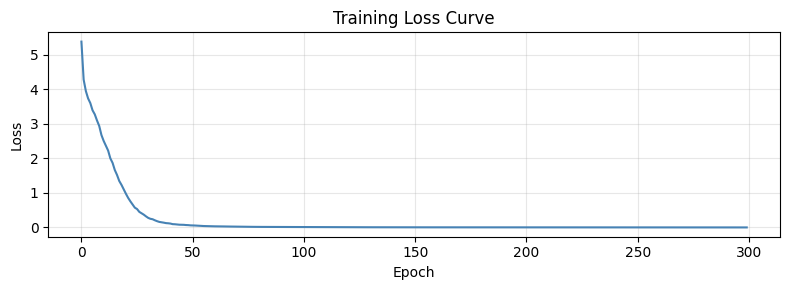

In [8]:
# Cell 8 - Training Loop

EPOCHS     = 300
LR         = 0.001
BATCH_SIZE = 32
CLIP       = 1.0

optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
criterion  = nn.CrossEntropyLoss(ignore_index=0)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode='min', factor=0.5, patience=25)

def train_epoch():
    model.train()
    total_loss = 0
    indices    = list(range(len(src_padded)))
    random.shuffle(indices)
    batches    = 0
    for i in range(0, len(indices), BATCH_SIZE):
        batch_idx  = indices[i:i + BATCH_SIZE]
        src_batch  = src_padded[batch_idx]
        tgt_batch  = tgt_padded[batch_idx]
        optimizer.zero_grad()
        output     = model(src_batch, tgt_batch, teacher_forcing_ratio=0.5)
        output_r   = output[:, 1:].reshape(-1, decoder.output_size)
        tgt_out    = tgt_batch[:, 1:].reshape(-1)
        loss       = criterion(output_r, tgt_out)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        total_loss += loss.item()
        batches    += 1
    return total_loss / max(batches, 1)

loss_history = []
best_loss    = float('inf')

print("Training started...\n")
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch()
    scheduler.step(loss)
    loss_history.append(loss)
    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), "best_model.pt")
    if epoch % 30 == 0:
        print(f"Epoch {epoch:>3}/{EPOCHS}  Loss: {loss:.4f}  Best: {best_loss:.4f}")

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print(f"\n✅ Training complete — Best loss: {best_loss:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='steelblue', linewidth=1.5)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Cell 9 - Hybrid Translator (Dictionary + Neural) with Voice Output

# ── Word-level Dictionary
ENG_DICT = {
    "i":"मि","me":"मिकें","my":"मेरु","mine":"मेरु",
    "we":"हम","our":"हमरु","us":"हमकें",
    "you":"तू","your":"तेरु","yours":"तेरु",
    "he":"वो","him":"उकें","his":"उकु",
    "she":"वा","her":"उकें","hers":"उकु",
    "they":"वो लोग","them":"उनकें","their":"उनकु",
    "this":"यू","that":"वो","here":"यख","there":"वख",
    "is":"च","are":"छन","am":"छौं","was":"छौ","were":"छिया",
    "not":"नि","no":"नि","yes":"आं",
    "go":"जा","going":"जांद","goes":"जांद","went":"गे",
    "come":"औ","coming":"ऐंद","comes":"ऐंद","came":"आई",
    "eat":"खा","eating":"खांद","eats":"खांद","ate":"खैं",
    "drink":"पी","drinking":"पींद","drinks":"पींद",
    "do":"कर","doing":"करद","does":"करद","did":"करि",
    "give":"दे","gives":"दींद","gave":"दिनि",
    "take":"ले","takes":"लींद","took":"लिनि",
    "sleep":"सो","sleeping":"सोंद","sleeps":"सोंद",
    "read":"पढ़","reads":"पढ़द","reading":"पढ़द",
    "write":"लिख","writes":"लिखद","writing":"लिखद",
    "see":"देख","sees":"देखद","saw":"देखि",
    "work":"काम कर","works":"काम करद","working":"काम करद",
    "cook":"बणा","cooks":"बणौंद","cooking":"बणौंद",
    "play":"खेल","plays":"खेलद","playing":"खेलद",
    "study":"पढ़","studies":"पढ़द","studying":"पढ़द",
    "live":"रौंद","lives":"रौंदन","lived":"रौंद",
    "love":"माया","like":"पसंद","want":"चांद",
    "know":"जाण","think":"सोच","feel":"महसूस करदु",
    "tell":"बतौंदि","teach":"पढ़ौंद","help":"मदद कर",
    "bring":"ल्यौंदु","fetch":"लींदु","miss":"याद ऐंदि",
    "bloom":"खिलदन","cover":"ढकि लींद","touch":"छूंदन",
    "sing":"गौंदि","fall":"पड़दि","graze":"चरदि",
    "mother":"ईजा","father":"बाबू","brother":"भुलु",
    "sister":"बैणि","grandmother":"आजी","grandfather":"दादा",
    "son":"छौं","daughter":"छ्वरी","friend":"दोस्त",
    "teacher":"मास्टर","farmer":"किसान","doctor":"डॉक्टर",
    "child":"बच्चा","children":"बच्चा","family":"परिवार",
    "uncle":"काका","aunt":"काकी","parents":"ईजा बाबू",
    "person":"मनखि","people":"लोग",
    "water":"पाणि","river":"गाड़","mountain":"पहाड़",
    "village":"गौं","forest":"जंगल","tree":"दरख्त",
    "flower":"फूल","flowers":"फूल","sun":"घाम",
    "moon":"चन्द्रमा","sky":"आकाश","rain":"बरखा",
    "snow":"बरफ","wind":"हवा","cloud":"बादल",
    "fog":"कुहरु","valley":"घाटी","path":"बाट",
    "field":"खेत","spring":"नौला","waterfall":"झरणु",
    "star":"तारा","stars":"तारा","air":"हवा",
    "soil":"माटि","grass":"घास","fruit":"फल",
    "food":"खाणु","milk":"दूद","rice":"चौंळ",
    "roti":"रोटि","bread":"रोटि","dal":"दाळ",
    "vegetable":"साग","vegetables":"साग","salt":"नूण",
    "ghee":"घ्यू","curd":"दही","tea":"चाय",
    "sweet":"मिठाई","sweets":"मिठाई","pickle":"अचार",
    "curry":"साग","flour":"आटु","apple":"सेब",
    "home":"घर","house":"घर","school":"स्कूल",
    "college":"कॉलेज","market":"बाजार","city":"शहर",
    "kitchen":"रसोई","library":"पुस्तकालय",
    "playground":"मैदान","orchard":"बगीचा",
    "uttarakhand":"उत्तराखंड","garhwal":"गढ़वाल","himalaya":"हिमालय",
    "name":"नाम","time":"बखत","day":"दिन","night":"राति",
    "morning":"भ्यार","evening":"साँझ","tomorrow":"भोल",
    "yesterday":"कल","today":"आज","week":"हफ्त","year":"साल",
    "exam":"परीक्षा","book":"किताब","bag":"बस्ता",
    "notebook":"कॉपी","homework":"गृहकार्य",
    "subject":"विषय","science":"विज्ञान","mathematics":"गणित",
    "holiday":"छुट्टी","festival":"त्यौहार","story":"कहाणि",
    "medicine":"दवाई","fever":"बुखार","money":"पैसा",
    "crop":"फसल","cow":"गौ","animal":"जनवर",
    "firewood":"लकड़ि","grain":"अनाज","smell":"खुशबू",
    "glass":"गिलास","rank":"पैलु",
    "good":"ठीक","very":"बोत","big":"ब्वड़","small":"छोटु",
    "hot":"तातु","cold":"ठंडु","fresh":"ताजि","tall":"ऊँचु",
    "heavy":"भारी","sweet":"मीठु","tasty":"मीठु","spicy":"तीखु",
    "sour":"खट्टु","bitter":"कड़वु","pure":"शुद्ध",
    "beautiful":"सुन्दर","dense":"घना","steep":"खड़ी",
    "fertile":"उपजाऊ","green":"हरयाळु","white":"सफेद",
    "happy":"रमाण","sad":"दुखि","angry":"गुस्सा",
    "tired":"थकि","lonely":"अकेलु","proud":"गर्व",
    "peaceful":"शांति","smart":"होशियार","old":"बुड्ड",
    "early":"जल्दी","fast":"तेज","hard":"बोत","well":"ठीक",
    "high":"ऊँचु","nearest":"नजीकि","favourite":"मनपसंद",
    "one":"एक","two":"दुइ","three":"तीन","four":"चार",
    "five":"पाँच","first":"पैलु","ten":"दस",
    "in":"मा","on":"मा","at":"मा","to":"कें","from":"बटी",
    "with":"कसांत","for":"क लिजि","of":"कु","by":"बटी",
    "and":"अर","but":"पर","or":"या","after":"बाद",
    "before":"पैलि","without":"बिना","than":"बटी",
    "what":"क्या","where":"कख","when":"कब","why":"कैलि",
    "who":"को","how":"कनै","which":"कौनु",
    "please":"कृपया","thank":"धन्यवाद","thanks":"धन्यवाद",
    "sorry":"माफ","hello":"नमस्कार","hi":"नमस्कार",
    "bye":"जय बदरी","now":"अभि","every":"रोज",
    "all":"सब","together":"मिलिक","back":"वापस",
    "less":"कम","more":"जादा","so":"बोत","too":"बि",
    "also":"भि","only":"सिर्फ","daily":"रोज","warm":"तातु",
}

HIN_DICT = {
    "मैं":"मि","मुझे":"मिकें","मुझको":"मिकें",
    "मेरा":"मेरु","मेरी":"मेरि","मेरे":"मेरा",
    "तुम":"तू","तुम्हें":"तिकें","तुम्हारा":"तेरु",
    "आप":"आप","वह":"वो","वो":"वो",
    "हम":"हम","हमारा":"हमरु","हमारी":"हमरि",
    "यह":"यू","यहाँ":"यख","वहाँ":"वख",
    "माँ":"ईजा","माता":"ईजा","पिता":"बाबू","पापा":"बाबू",
    "भाई":"भुलु","बहन":"बैणि","दादी":"आजी","दादा":"दादा",
    "बेटा":"छौं","बेटी":"छ्वरी","चाचा":"काका","चाची":"काकी",
    "दोस्त":"दोस्त","शिक्षक":"मास्टर","किसान":"किसान",
    "पानी":"पाणि","जल":"पाणि","घर":"घर",
    "गाँव":"गौं","गांव":"गौं","पहाड़":"पहाड़","पर्वत":"पहाड़",
    "नदी":"गाड़","जंगल":"जंगल","सूरज":"घाम","धूप":"घाम",
    "चाँद":"चन्द्रमा","आकाश":"आकाश","बारिश":"बरखा","बर्षा":"बरखा",
    "बर्फ":"बरफ","हवा":"हवा","बादल":"बादल","कोहरा":"कुहरु",
    "फूल":"फूल","पेड़":"दरख्त","रास्ता":"बाट","झरना":"झरणु",
    "घाटी":"घाटी","खेत":"खेत","बगीचा":"बगीचा",
    "रात":"राति","दिन":"दिन","सुबह":"भ्यार","शाम":"साँझ",
    "आज":"आज","कल":"भोल","कल":"कल",
    "दूध":"दूद","चावल":"चौंळ","रोटी":"रोटि","दाल":"दाळ",
    "सब्जी":"साग","नमक":"नूण","घी":"घ्यू","चाय":"चाय",
    "मिठाई":"मिठाई","खाना":"खाणु","फल":"फल",
    "स्कूल":"स्कूल","कॉलेज":"कॉलेज","बाजार":"बाजार",
    "शहर":"शहर","किताब":"किताब","बस्ता":"बस्ता",
    "गणित":"गणित","परीक्षा":"परीक्षा","छुट्टी":"छुट्टी",
    "त्यौहार":"त्यौहार","पढ़ाई":"पढ़ाई",
    "है":"च","हैं":"छन","हूँ":"छौं","था":"छौ","थे":"छिया",
    "जाता":"जांद","जाती":"जांदि","जाते":"जांदन",
    "जा":"जा","जाओ":"जा","जाना":"जाणु","जा रहा":"जांद",
    "आता":"ऐंद","आती":"ऐंदि","आओ":"औ","आ":"औ",
    "खाता":"खांद","खाती":"खांदि","खाओ":"खा","खाना":"खाणु",
    "पीता":"पींद","पीती":"पींदि","पीओ":"पी",
    "करता":"करद","करती":"करदि","करते":"करदन","करो":"कर",
    "देता":"दींद","देती":"दींदि","दो":"दे",
    "सोता":"सोंद","सोती":"सोंदि",
    "पढ़ता":"पढ़द","पढ़ती":"पढ़दि","पढ़ो":"पढ़",
    "लिखता":"लिखद","लिखती":"लिखदि",
    "रहता":"रौंद","रहती":"रौंदि","रहते":"रौंदन",
    "बनाता":"बणौंद","बनाती":"बणौंदि",
    "करता है":"करद","जाता है":"जांद","आता है":"ऐंद",
    "नहीं":"नि","ना":"नि","हाँ":"आं",
    "बहुत":"बोत","थोड़ा":"थौड़","सब":"सब",
    "और":"अर","लेकिन":"पर","या":"या",
    "में":"मा","पर":"मा","से":"बटी","को":"कें",
    "का":"कु","की":"कि","के":"का","के लिए":"क लिजि",
    "के साथ":"कसांत","मिलकर":"मिलिक",
    "क्या":"क्या","कहाँ":"कख","कब":"कब",
    "क्यों":"कैलि","कौन":"को","कैसे":"कनै",
    "कितना":"कतु","कितनी":"कति",
    "अच्छा":"ठीक","अच्छी":"ठीक","अच्छे":"ठीक",
    "बड़ा":"ब्वड़","बड़ी":"ब्वड़ि","छोटा":"छोटु","छोटी":"छोटि",
    "गरम":"तातु","ठंडा":"ठंडु","ठंडी":"ठंडि",
    "सुंदर":"सुन्दर","खुश":"रमाण","दुखी":"दुखि",
    "भूख":"भूख","प्यास":"तिरास","याद":"याद",
    "प्यार":"माया","गर्व":"गर्व","शांति":"शांति",
    "नमस्ते":"नमस्कार","धन्यवाद":"धन्यवाद","माफ":"माफ",
    "रोज":"रोज","जल्दी":"जल्दी","वापस":"वापस",
    "उत्तराखंड":"उत्तराखंड","हिमालय":"हिमालय","गढ़वाल":"गढ़वाल",
    "गाय":"गौ","फसल":"फसल","किसान":"किसान",
    "बुखार":"बुखार","दवाई":"दवाई","सिरदर्द":"सिर दुखद",
}

def detect_language(text):
    deva = sum(1 for c in text if '\u0900' <= c <= '\u097F')
    return 'hindi' if deva > len(text) * 0.15 else 'english'

def dictionary_translate(sentence):
    lang  = detect_language(sentence)
    d     = HIN_DICT if lang == 'hindi' else {k: v for k, v in ENG_DICT.items()}
    words = sentence.strip().split()
    out   = []
    found = 0
    i     = 0
    while i < len(words):
        w = words[i].lower().strip('।,.!?')
        # Try bigram first
        if i + 1 < len(words):
            bigram = w + " " + words[i+1].lower().strip('।,.!?')
            if bigram in d:
                out.append(d[bigram])
                found += 2
                i += 2
                continue
        if w in d:
            out.append(d[w])
            found += 1
        else:
            out.append(None)
        i += 1
    coverage = round(found / len(words) * 100) if words else 0
    return out, coverage

def neural_translate(sentence, max_len=50):
    model.eval()
    with torch.no_grad():
        t   = sentence_to_tensor(sentence, src_vocab)
        src = pad_batch([t]).to(device)
        enc_out, hidden = model.encoder(src)
        x   = torch.tensor([tgt_vocab.word2idx["<SOS>"]]).to(device)
        out = []
        for _ in range(max_len):
            pred, hidden = model.decoder(x, hidden, enc_out)
            top1 = pred.argmax(1)
            word = tgt_vocab.idx2word.get(top1.item(), "<UNK>")
            if word == "<EOS>":
                break
            out.append(word)
            x = top1
    return " ".join(out)

def hybrid_translate(sentence):
    tokens, coverage = dictionary_translate(sentence)

    if coverage >= 70:
        result = " ".join(t for t in tokens if t is not None)
        method = f"Dictionary ({coverage}%)"
    elif coverage >= 40:
        neural = neural_translate(sentence)
        # Fill known tokens into neural result where possible
        known  = [t for t in tokens if t is not None]
        result = neural if len(neural.split()) >= 3 else " ".join(known)
        method = f"Hybrid ({coverage}% dict + neural)"
    else:
        result = neural_translate(sentence)
        method = f"Neural ({coverage}% dict coverage)"

    return result.strip(), method

def speak_garhwali(text):
    try:
        path = "/tmp/garhwali_out.mp3"
        gTTS(text=text, lang='hi', slow=False).save(path)
        display(Audio(path, autoplay=True))
        return path
    except Exception as e:
        print(f"Voice error: {e}")
        return None

def translate_and_speak(sentence):
    print(f"Input    : {sentence}")
    result, method = hybrid_translate(sentence)
    print(f"Garhwali : {result}")
    print(f"Method   : {method}")
    speak_garhwali(result)
    print("-" * 50)
    return result

# ── Quick Test ───────────────────────────────────────────────
tests = [
    "i am going home",
    "my mother is very good",
    "the mountain is very big",
    "where are you going",
    "i am hungry",
    "मैं घर जाता हूँ",
    "पानी कहाँ है",
    "मुझे भूख लगी है",
]

print("=" * 50)
for s in tests:
    translate_and_speak(s)

print("✅ Hybrid translator ready")

Input    : i am going home
Garhwali : मि छौं जांद घर
Method   : Dictionary (100%)


--------------------------------------------------
Input    : my mother is very good
Garhwali : मेरु ईजा च बोत ठीक
Method   : Dictionary (100%)


--------------------------------------------------
Input    : the mountain is very big
Garhwali : पहाड़ च बोत ब्वड़
Method   : Dictionary (80%)


--------------------------------------------------
Input    : where are you going
Garhwali : कख छन तू जांद
Method   : Dictionary (100%)


--------------------------------------------------
Input    : i am hungry
Garhwali : ईजा बोत ठीक च
Method   : Hybrid (67% dict + neural)


--------------------------------------------------
Input    : मैं घर जाता हूँ
Garhwali : मि घर जांद छौं
Method   : Dictionary (100%)


--------------------------------------------------
Input    : पानी कहाँ है
Garhwali : पाणि कख च
Method   : Dictionary (100%)


--------------------------------------------------
Input    : मुझे भूख लगी है
Garhwali : मिकें भूख च
Method   : Dictionary (75%)


--------------------------------------------------
✅ Hybrid translator ready


In [10]:
# Cell 10 - Gradio Web UI

def gradio_translate(input_text):
    if not input_text.strip():
        return "", "", None
    result, method = hybrid_translate(input_text.strip())
    audio_path = "/tmp/output.mp3"
    try:
        gTTS(text=result, lang='hi', slow=False).save(audio_path)
    except:
        audio_path = None
    return result, method, audio_path

examples = [
    ["i am going home"],
    ["my mother is very good"],
    ["the mountain is very big"],
    ["where are you going"],
    ["i am hungry"],
    ["the village is beautiful"],
    ["good morning"],
    ["i love my family"],
    ["मैं घर जाता हूँ"],
    ["पानी कहाँ है"],
    ["मुझे भूख लगी है"],
    ["गाँव बहुत सुंदर है"],
    ["मेरी माँ बहुत अच्छी है"],
    ["आज बारिश हो रही है"],
]

with gr.Blocks(title="Garhwali Translator", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🏔️ गढ़वाली भाषा अनुवादक — Garhwali Language Translator
    **Model:** Encoder-Decoder GRU + Bahdanau Attention + Dictionary Hybrid
    **Languages:** English → Garhwali | Hindi → Garhwali
    **Region:** Uttarakhand, India
    ---
    """)

    with gr.Row():
        with gr.Column(scale=1):
            input_box = gr.Textbox(
                label="✍️ Input Sentence (English or Hindi)",
                placeholder="Type here...  e.g.  my mother is very good",
                lines=4
            )
            translate_btn = gr.Button("🔄 Translate to Garhwali", variant="primary", size="lg")
            gr.Examples(examples=examples, inputs=input_box, label="📋 Try these examples")

        with gr.Column(scale=1):
            output_box = gr.Textbox(
                label="🏔️ Garhwali Translation",
                lines=4,
                interactive=False
            )
            method_box = gr.Textbox(
                label="⚙️ Translation Method",
                interactive=False
            )
            audio_out = gr.Audio(
                label="🔊 Voice Output (Garhwali)",
                type="filepath",
                autoplay=True
            )

    with gr.Accordion("📊 Project Details", open=False):
        gr.Markdown(f"""
        | Detail | Value |
        |---|---|
        | Architecture | Encoder-Decoder GRU with Bahdanau Attention |
        | Approach | Hybrid — Dictionary + Neural Model |
        | Source Vocabulary | {src_vocab.n_words} words |
        | Target Vocabulary | {tgt_vocab.n_words} words |
        | Training Pairs | {len(data)} parallel sentences |
        | Training Epochs | 300 |
        | Voice Engine | Google Text-to-Speech (gTTS) |
        | Language | Low-resource — Garhwali (Uttarakhand) |
        | Developer | College Project |
        """)

    translate_btn.click(
        fn=gradio_translate,
        inputs=input_box,
        outputs=[output_box, method_box, audio_out]
    )
    input_box.submit(
        fn=gradio_translate,
        inputs=input_box,
        outputs=[output_box, method_box, audio_out]
    )

demo.launch(share=True, debug=False)
print("✅ App launched — open the public link above")

/tmp/ipykernel_1823/3710326467.py:31: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Garhwali Translator", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2494e2ebd716c5f6ac.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ App launched — open the public link above
